In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from diasense.config import (
    CLINICAL_FEATURES, CLUSTERING_FEATURES, ZERO_AS_MISSING,
    MODELS_DIR, PROCESSED_DATA_DIR, FIGURES_DIR,
)
from diasense.data import load_raw_data
from diasense.preprocessing import (
    build_preprocessing_pipeline, detect_outliers_iqr, inverse_scale, save_artifact,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)

df = load_raw_data()
print("Loaded:", df.shape)

Loaded: (768, 8)


In [13]:
pipe = build_preprocessing_pipeline()
pipe

Pipeline(steps=[('zero_to_nan',
                 HiddenZeroToNaN(columns=['Glucose', 'BloodPressure',
                                          'SkinThickness', 'Insulin', 'BMI'])),
                ('scaler', FrameStandardScaler()), ('capper', OutlierCapper()),
                ('imputer', FrameKNNImputer())])

In [14]:
df_nan = pipe[:1].transform(df[CLINICAL_FEATURES])   # HiddenZeroToNaN only

display(
    df_nan.isna().sum().to_frame("NaN_after_zero_to_NaN").query("NaN_after_zero_to_NaN > 0")
)

,NaN_after_zero_to_NaN
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [ ]:
pipe.fit(df[CLINICAL_FEATURES])

df_prepared = pipe.transform(df[CLINICAL_FEATURES])  # scaled space => K-Means-ready

assert df_prepared.isna().sum().sum() == 0, "Imputation failed: NaN remain!"
print("Pipeline fitted. Output:", df_prepared.shape, "| mean=0, std=1:")
display(df_prepared.describe().round(3))

Pipeline fitted. Output: (768, 8) | mean≈0, std≈1:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,-0.002,-0.003,-0.001,-0.019,-0.035,-0.009,-0.019,-0.002
std,0.995,0.999,0.971,0.877,0.764,0.977,0.920,0.994
min,-1.142,-2.546,-3.002,-2.116,-1.193,-2.060,-1.190,-1.042
25%,-0.845,-0.743,-0.679,-0.607,-0.558,-0.716,-0.689,-0.786
50%,-0.251,-0.154,-0.033,-0.015,-0.215,-0.039,-0.300,-0.361
75%,0.640,0.608,0.614,0.559,0.300,0.599,0.466,0.660
max,3.002,2.534,3.002,3.003,3.004,3.002,3.002,3.002


In [ ]:
df_capped_only = inverse_scale(pipe, pipe[:3].transform(df[CLINICAL_FEATURES]))  # capped & NaN kept
df_clean = inverse_scale(pipe, df_prepared)                                      # capped + imputed

report = pd.DataFrame({
    "before_treatment": detect_outliers_iqr(df_nan, CLINICAL_FEATURES),
    "after_treatment": detect_outliers_iqr(df_clean, CLINICAL_FEATURES),
})
display(report)

,before_treatment,after_treatment
Pregnancies,4,4
Glucose,0,0
BloodPressure,14,14
SkinThickness,3,6
Insulin,24,27
BMI,8,8
DiabetesPedigreeFunction,29,29
Age,9,9


A few IQR flags may remain after treatment (e.g., Age, BMI). That is expected: we capped at **±3σ** (soft, protects the high-risk tail), not IQR×1.5. Leftover flags sit on features **excluded from clustering** anyway.

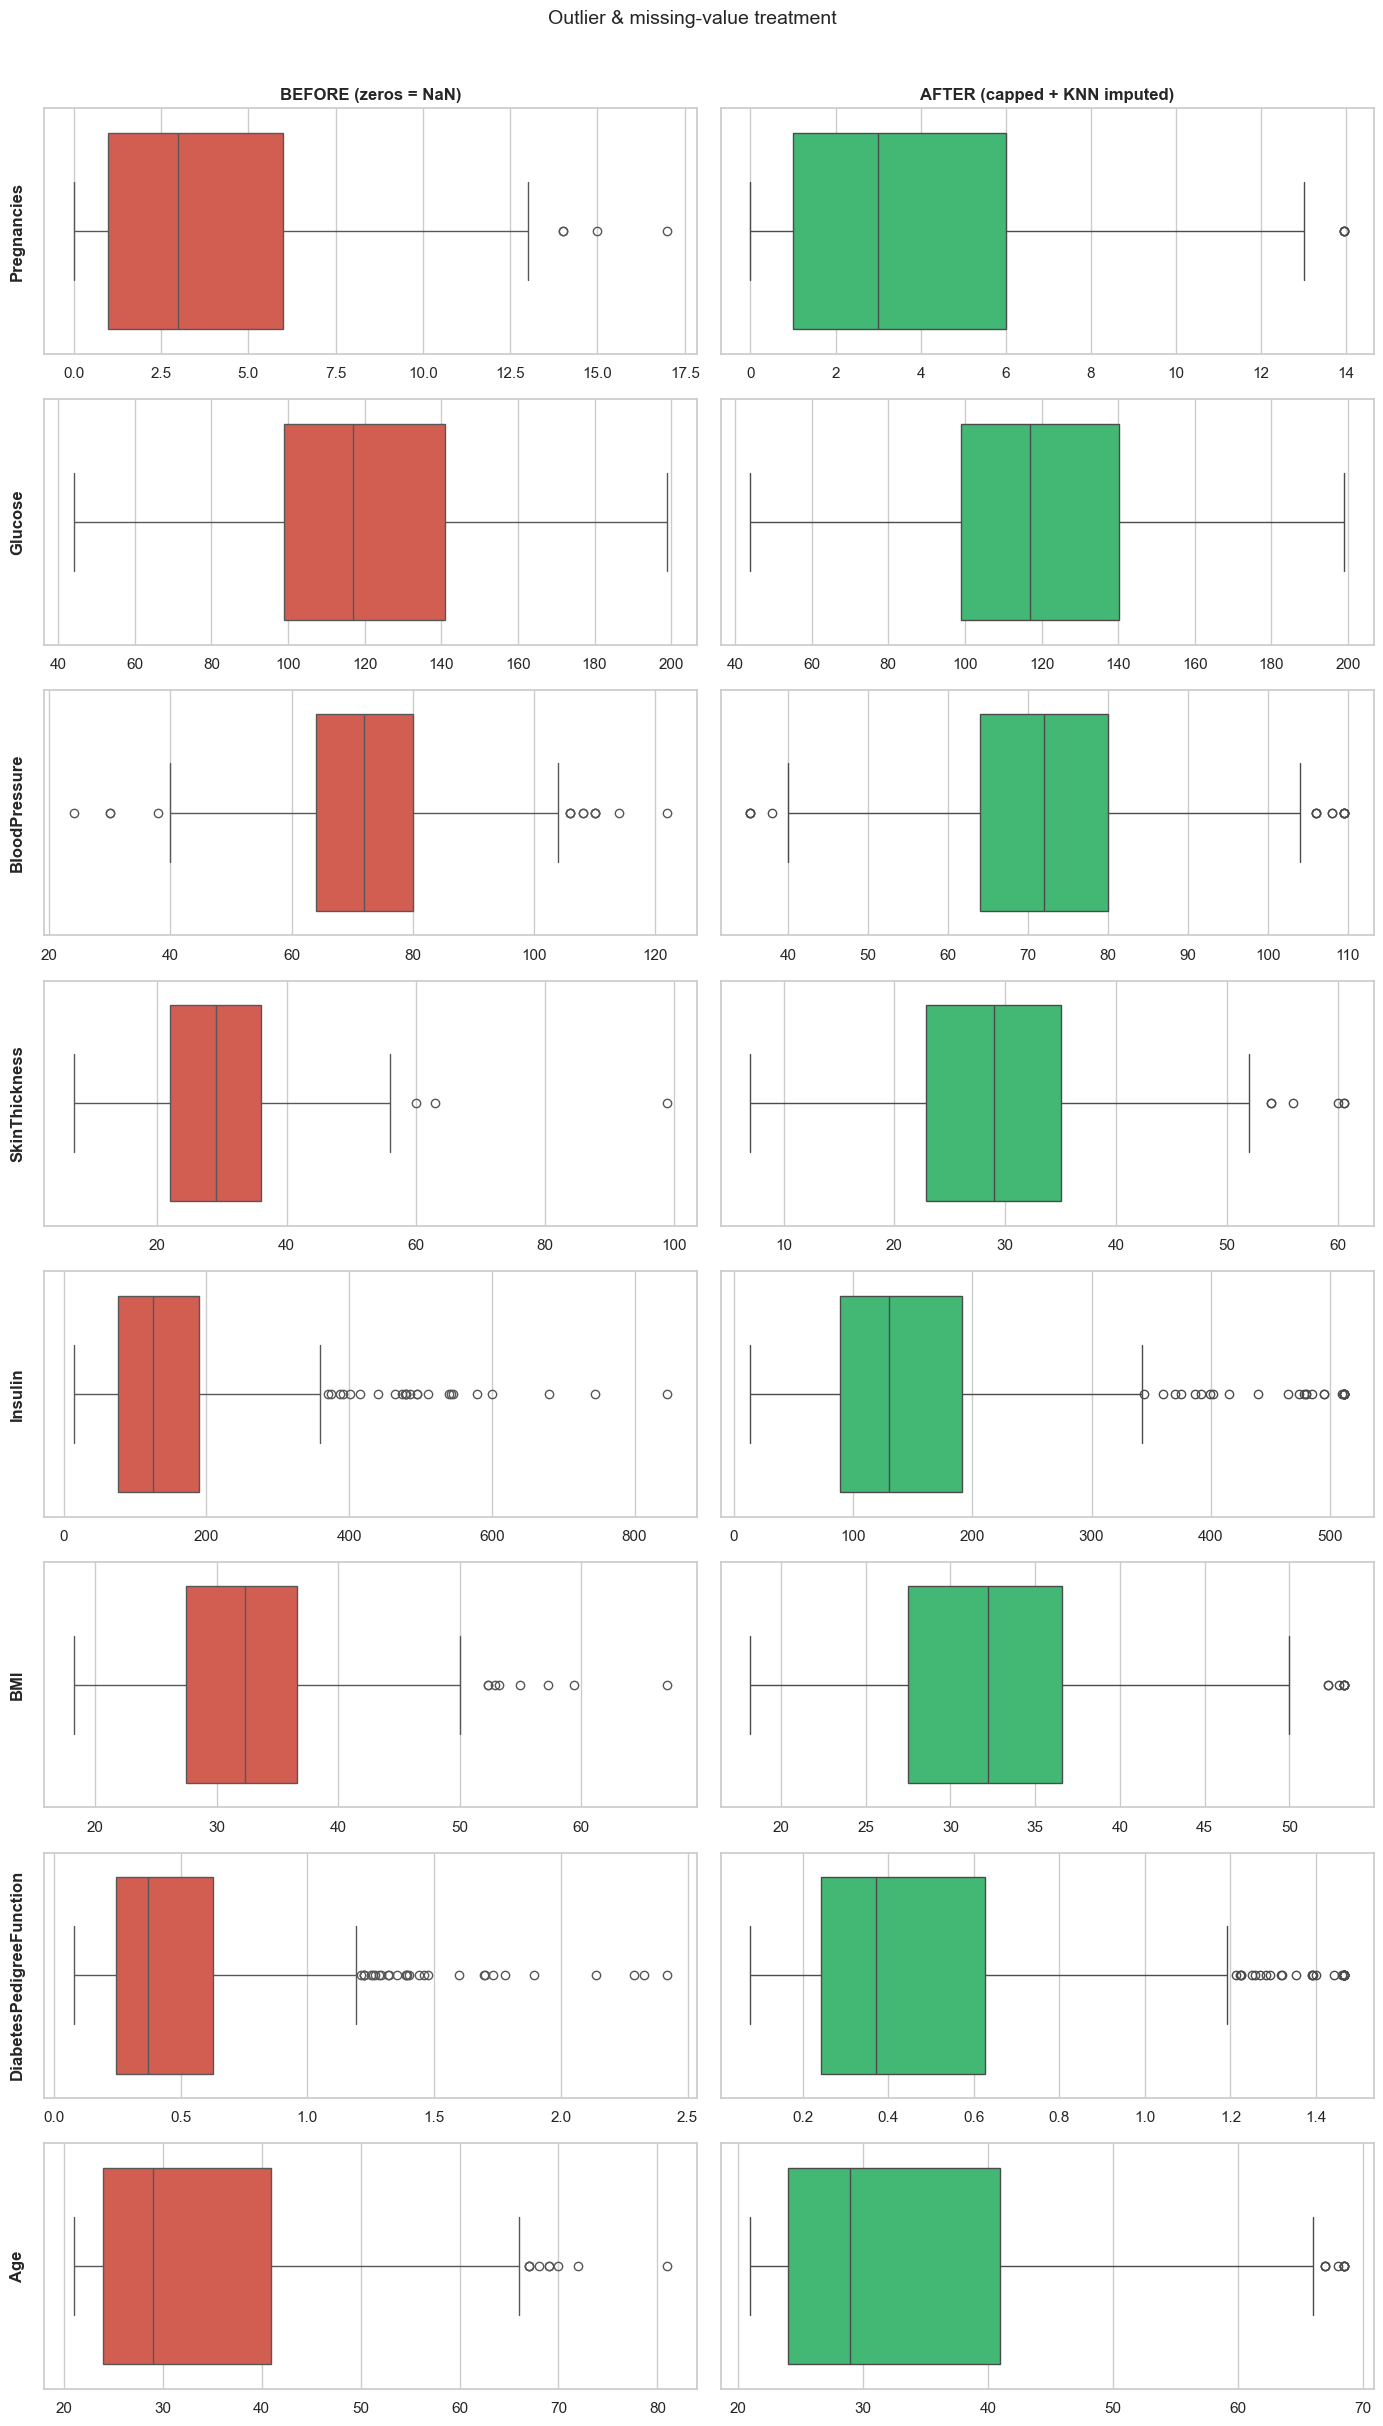

In [17]:
# before/after boxplots (one row per feature, before | after)

fig, axes = plt.subplots(len(CLINICAL_FEATURES), 2, figsize=(14, 3 * len(CLINICAL_FEATURES)))
for i, col in enumerate(CLINICAL_FEATURES):
    sns.boxplot(x=df_nan[col],   ax=axes[i, 0], color="#e74c3c")
    sns.boxplot(x=df_clean[col], ax=axes[i, 1], color="#2ecc71")
    axes[i, 0].set_ylabel(col, fontweight="bold")
    axes[i, 0].set_xlabel("")
    axes[i, 1].set_xlabel("")
axes[0, 0].set_title("BEFORE (zeros = NaN)",        fontsize=12, fontweight="bold")
axes[0, 1].set_title("AFTER (capped + KNN imputed)", fontsize=12, fontweight="bold")
plt.suptitle("Outlier & missing-value treatment", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "preprocessing_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

,coefficient_of_variation
Pregnancies,0.873
DiabetesPedigreeFunction,0.654
Insulin,0.599
Age,0.352
SkinThickness,0.317
Glucose,0.251
BMI,0.209
BloodPressure,0.166


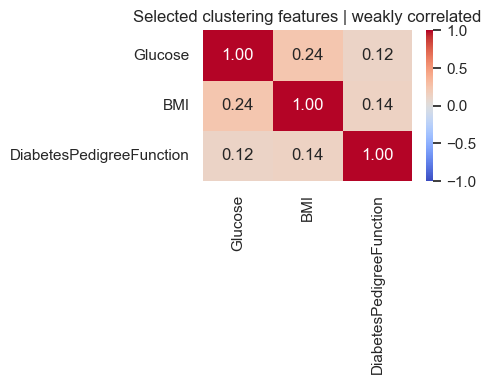

In [18]:
# coefficient of variation (std / mean)
cv = (df_clean.std() / df_clean.mean()).sort_values(ascending=False)
display(cv.round(3).to_frame("coefficient_of_variation"))

# The 3 selected axes are weakly correlated so each brings independent signal
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(df_clean[CLUSTERING_FEATURES].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Selected clustering features | weakly correlated")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "preprocessing_selected_corr.png", dpi=150, bbox_inches="tight")
plt.show()

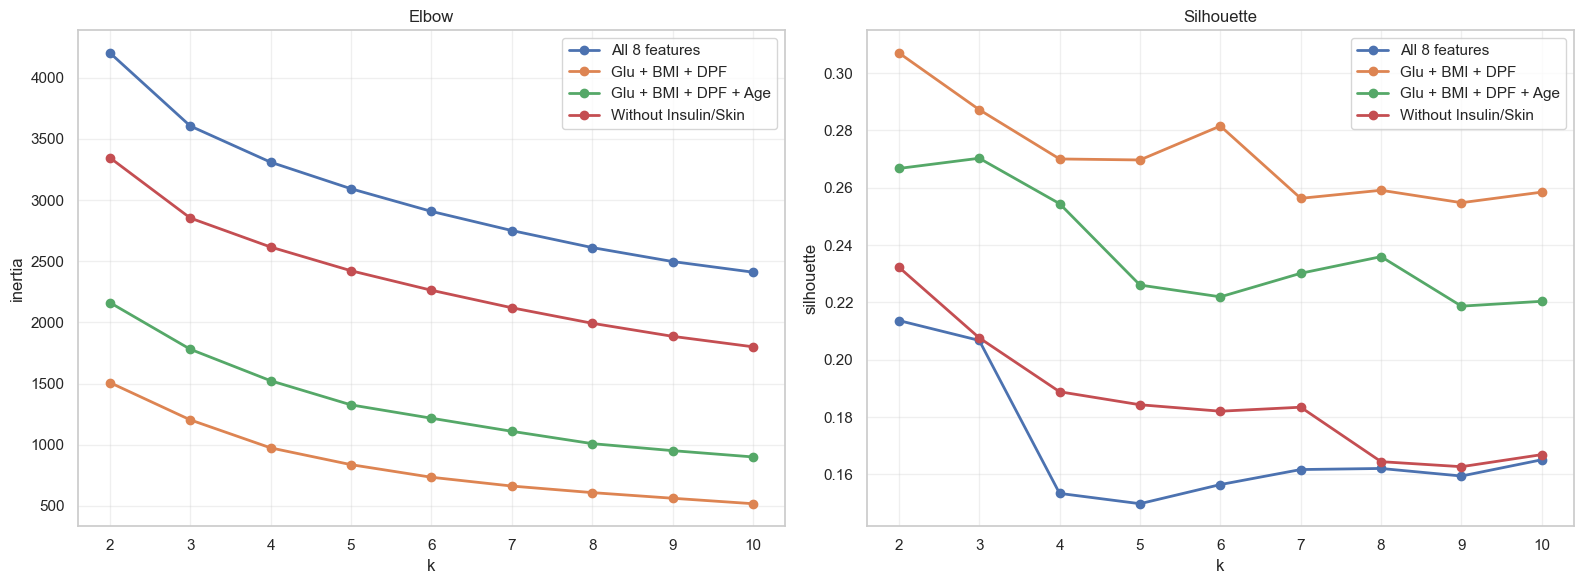

Best silhouette per feature set:


,feature_set,k,silhouette
27,Glu + BMI + DPF,2,0.307033
19,Glu + BMI + DPF + Age,3,0.270283
9,Without Insulin/Skin,2,0.232297
0,All 8 features,2,0.213678


In [ ]:
import matplotlib.pyplot as plt

from diasense.clustering_diagnostics import compare_feature_sets, plot_feature_set_curves


feature_sets = {
    "All 8 features": ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"],
    "Without Insulin/Skin": ["Pregnancies","Glucose","BloodPressure","BMI","DiabetesPedigreeFunction","Age"],
    "Glu + BMI + DPF + Age": ["Glucose","BMI","DiabetesPedigreeFunction","Age"],
    "Glu + BMI + DPF": ["Glucose","BMI","DiabetesPedigreeFunction"],
}



results = compare_feature_sets(df_prepared, feature_sets, k_values=range(1, 11))

fig = plot_feature_set_curves(results)
plt.show()


best = results.loc[results.groupby("feature_set")["silhouette"].idxmax()]
print("Best silhouette per feature set:")
display(best[["feature_set","k","silhouette"]].sort_values("silhouette", ascending=False))

### Feature selection decision

CV ranks features like Insulin/Pregnancies highest, **but**:
- Insulin's variability is inflated - 49% of its values are imputed;
- Pregnancies is gestational-specific and weakly correlated with the risk trio (r ≤ 0.13).

| Feature set | Best silhouette |
|---|---|
| All 8 | 0.221 (k=2) |
| Without Insulin/Skin | 0.230 (k=2) |
| Glucose+BMI+DPF+Age | 0.268 (k=3) |
| **Glucose+BMI+DPF** | **0.306 (k=2)**  |

Chosen: **Glucose, BMI, DiabetesPedigreeFunction** - best clustering quality, matches the brief's
clinical risk rule, and the resulting high-risk cluster crosses ALL three thresholds
(Glucose 150.3 > 126, BMI 36.9 > 30, DPF 0.63 > 0.5).

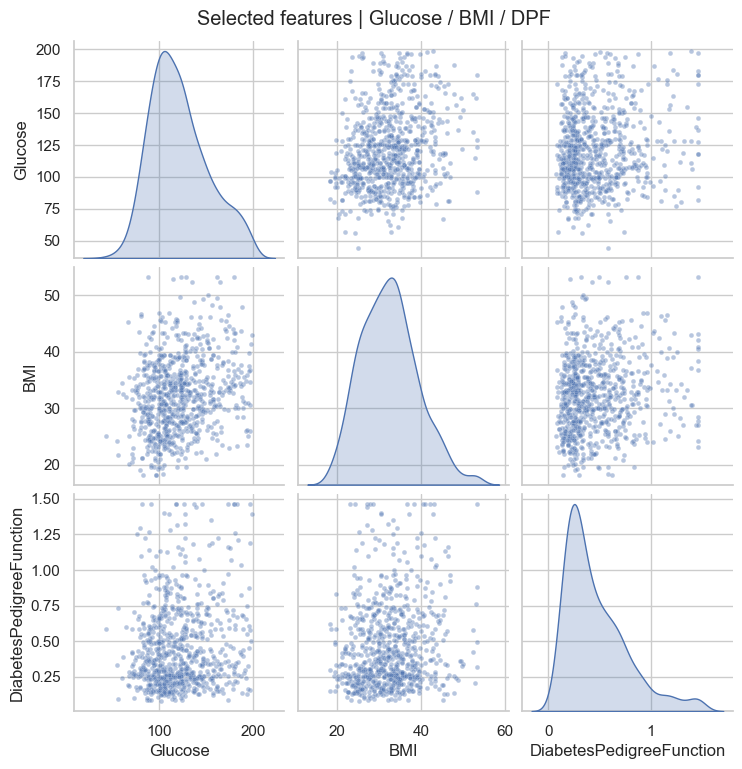

In [19]:
# Pairplot of the 3 selected clustering features
sns.pairplot(df_clean[CLUSTERING_FEATURES], diag_kind="kde",
             plot_kws={"alpha": 0.4, "s": 12})
plt.suptitle("Selected features | Glucose / BMI / DPF", y=1.02)
plt.savefig(FIGURES_DIR / "preprocessing_pairplot_selected.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
save_artifact(pipe, MODELS_DIR / "preprocessing_pipeline.joblib")

df_prepared.to_csv(PROCESSED_DATA_DIR / "dataset_preprocessed.csv", index=False)
df_clean.to_csv(PROCESSED_DATA_DIR / "dataset_clean.csv", index=False)

print("Saved: preprocessing_pipeline.joblib, dataset_preprocessed.csv, dataset_clean.csv")

Saved: preprocessing_pipeline.joblib, dataset_preprocessed.csv, dataset_clean.csv
